In [ ]:
# Bagging
"""
Bagging, or Bootstrap Aggregating, is an ensemble technique in which multiple subsets of the original training dataset are created using bootstrap sampling. These subsets are then used to train multiple models, and their predictions are combined to make the final prediction.
The subsets are created by randomly sampling data with replacement. The size of the subset created for bagging can be less than, equal to, or related to the original dataset size, depending on the sampling configuration.

Bagging Meta-Estimator
Bagging Meta-Estimator is an ensemble sampling algorithm that can be used for both classification and regression problems.
It follows the typical bagging technique:
1. Multiple bootstrap samples are created from the training dataset.
2. A base estimator is trained on each sample.
3. Each estimator makes its own prediction.
4. The predictions are combined to make the final prediction.

Random Forest
Random Forest is another ensemble machine learning algorithm that follows the bagging technique.
It can be considered an extension of the bagging approach, specifically designed using Decision Trees as the base estimators.
In Random Forest:
- Multiple Decision Trees are trained.
- Each tree is trained using a bootstrap sample of the training data.
- A random subset of features is also considered when splitting nodes.
- The predictions of all the trees are combined to produce the final prediction.

For classification, Random Forest generally uses majority voting, while for regression, it generally uses averaging.

Therefore:

Bagging → Multiple samples → Multiple base models → Combine predictions

Random Forest → Bagging + Multiple Decision Trees + Random feature selection"""

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
from sklearn.datasets import make_moons
x,y= make_moons(n_samples=1000,noise=0.2)
df = {"x1":x[:,0],"x2":x[:,1],"y":y}
dataset = pd.DataFrame(df)
dataset.head(3)

,x1,x2,y
0,-0.110275,-0.303759,1
1,1.926368,0.224692,1
2,1.945851,0.292524,1


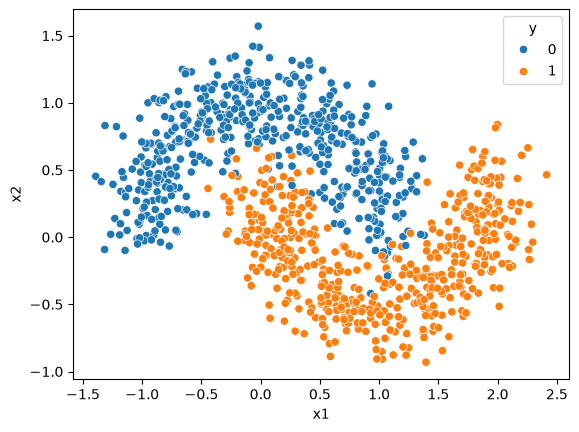

In [3]:
sns.scatterplot(x="x1",y="x2", data=dataset , hue="y")
plt.show()


In [4]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y, random_state=42 , test_size=0.2)

In [6]:
from sklearn.ensemble import BaggingClassifier , RandomForestClassifier
from sklearn.svm import SVC

In [7]:
sv = SVC()
sv.fit(x_train , y_train)
sv.score(x_test , y_test)*100 , sv.score(x_train , y_train)*100 , sv.score(x_test , y_test)*100-sv.score(x_train , y_train)*100

(97.5, 97.25, 0.25)

In [8]:
bg = BaggingClassifier(estimator=SVC(),n_estimators=50)
bg.fit(x_train , y_train)
bg.score(x_test , y_test)*100 , bg.score(x_train , y_train)*100 , bg.score(x_test , y_test)*100-bg.score(x_train , y_train)*100

(97.5, 97.125, 0.375)

In [9]:
rf = RandomForestClassifier(n_estimators=50)
rf.fit(x_train , y_train)
rf.score(x_test , y_test)*100 , rf.score(x_train , y_train)*100 , rf.score(x_test , y_test)*100-rf.score(x_train , y_train)*100

(96.5, 100.0, -3.5)